# How to do single-cell analysis of ISS data:

This notebook guides you through the different steps that will eventually allow you to analyse ISS data at the single cell level.

To complete this tutorial you should have completed the previous steps, and you will need the following ingredients.

1. Your decoded data, in the standard decoded format as we have generated from the `ISS_decoding` notebook.
2. A segmentation mask in .nzp format produced with either `Stardist`, `Cellpose` (see our tutorials) or whichever method you prefer.
3. time, patience, and some knowledge of single-cell analysis.


The analysis is based on Scanpy (documentation in  https://scanpy.readthedocs.io/en/stable/index.html) and Squidpy (documentation in https://squidpy.readthedocs.io/en/stable/)


## Import packages
We import the necessary packages. `ISS_postprocessing` includes some modules requiring a functional and properly installed CUDA-compatible GPU. They will work but they might be slower on CPU.

In [1]:
import ISS_postprocessing.annotated_objects as ANN
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
from pathlib import Path


## Integrate ISS data with the segmentation mask and create an AnnData object

This step takes the decoded ISS spots and assigns each spot to a cell label based on its `(x, y)` position, using a pre-computed segmentation mask to define cell boundaries. After optional filtering and coordinate conversion, the result is stored as an **AnnData** object (`.h5ad`).

### Function parameters

`input_dir` *(str)*: Path to the parent directory containing the preprocessed region folders (e.g., `/R1/`, `/R2/`, …), created during preprocessing.  

`regions` *(str)*: Identifier of the region to process (e.g., `R1`).  

`segmentation_method` *(str)*: Which mask to use: `"cellpose"` or `"stardist"` (must match the files you saved). 

`dense` *(bool, default=True)*: Which decoding to use (`dense` or
  sparse), must match the files you saved.  

`filter_data` *(bool, default=True)*: Whether to filter decoded spots by a quality metric.  

`metric` *(str, default="quality_minimum")*: Column in the spots table used for filtering (e.g., `quality_minimum`, `quality_mean`, or `distance`).  

`value` *(float, default=0.5)*: Threshold used with `metric` (e.g., `quality_minimum > 0.4–0.5`, or `distance < value`).  

`write_h5ad` *(bool, default=True)*: If `True`, writes the resulting AnnData to disk.  

`convert_coords` *(bool, default=True)*: If `True`, converts decoded coordinates to **pixel units** so they align with the segmentation mask.  

`conversion_factor` *(float, default=0.1625)*: XY pixel size in **µm/pixel**; coordinates are converted via `x = xc / conversion_factor` and `y = yc / conversion_factor`.

> Getting `convert_coords` and `conversion_factor` right is critical. The segmentation mask is in pixel coordinates; if your decoded spots are in physical units (e.g., µm), convert them to pixels. A mismatch will misassign spots to cells and invalidate downstream analyses.


> **Note:**  
> You need to specify the names of the regions you want to post-process.  
> Multiple regions can be processed in one run, and they will all be analyzed using the same parameters.  
> In most cases this is fine, but there may be situations where individual regions need to be treated differently.  


In [2]:
input_dir = '/path/to/regions/'
regions = ['R1', 'R2', 'R3']

In [3]:
input_dir =  '/mnt/DATA/ext_home/saga/test/saga/output_tif_autosaved/redlionfish/'
regions = ['R1']

In [4]:
for region in regions:  
    
        ad = ANN.create_anndata_obj(
            input_dir, 
            region,
            segmentation_method = 'cellpose',
            dense = True,
            filter_data = True, 
            metric = 'quality_minimum', 
            write_h5ad = True,
            value = 0.4,
            convert_coords = False, 
            conversion_factor = 0.1625)


Processing region: R1
AnnData file already exists, reloading: /mnt/DATA/ext_home/saga/test/saga/output_tif_autosaved/redlionfish/R1/postprocessing/segmentation/R1_anndata_cellpose.h5ad


## Concatenating multiple AnnData objects for joint analysis

When working with multiple regions, you can merge their AnnData objects into a single dataset. This lets you run joint QC, normalization, clustering, and plotting while still tracking each cell’s origin. The code below sets `obs['region_id']` to the region/section identifier so you can filter or visualize by region as needed.


In [5]:
ad =  ANN.concat_anndata(
        regions, 
        input_dir,
        segmentation_method='cellpose'
                  )


Reading: /mnt/DATA/ext_home/saga/test/saga/output_tif_autosaved/redlionfish/R1/postprocessing/segmentation/R1_anndata_cellpose.h5ad


In the following step some useful metrics about the experiment are calculated. 

In [6]:
# Compute standard QC metrics (per cell and per gene)
sc.pp.calculate_qc_metrics(
    ad,
    percent_top=None,
    log1p=False,
    inplace=True
)


This block visualizes the distribution of `total_counts` per cell to help with basic QC:

1) **Very low counts** (especially zeros) are uninformative for clustering and should typically be filtered out.

2) **Unusually high counts** can indicate segmentation artifacts or merged cells. For example, if most cells have ~30 counts, cells with hundreds of counts are suspicious.

Use these patterns to choose sensible lower/upper cutoffs; exact thresholds are dataset-dependent.


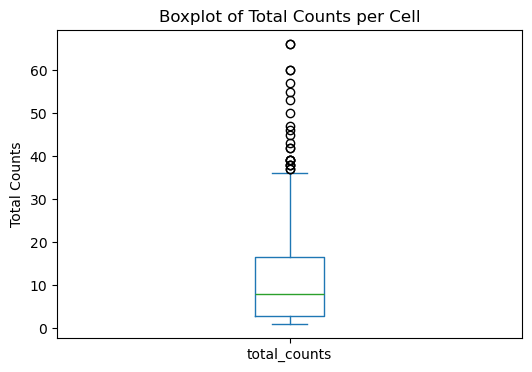

In [7]:
# Boxplot of per-cell total counts
ad.obs["total_counts"].plot(kind="box", figsize=(6, 4))
plt.title("Boxplot of Total Counts per Cell")
plt.ylabel("Total Counts")
plt.show()


Similar considerations apply to the metric `n_genes_by_counts`, which reports **how many unique genes are detected per cell**. Cells with only one—or very few—genes are often suspicious and may be filtered out.

Keep in mind that sensible thresholds depend on your ISS panel size, detection efficiency, and sample quality. The boxplots above are intended for visual inspection of these QC metrics to help you choose meaningful filtering cutoffs in the next step.


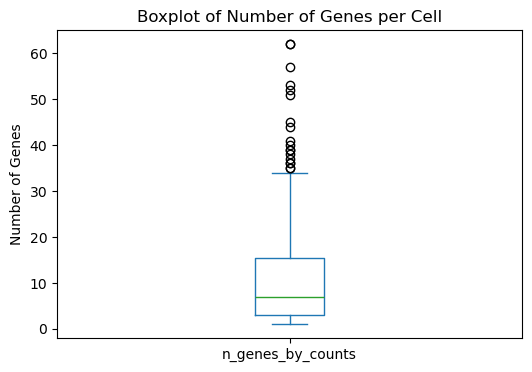

In [8]:
# Boxplot of the number of genes detected per cell
ad.obs["n_genes_by_counts"].plot(kind="box", figsize=(6, 4))
plt.title("Boxplot of Number of Genes per Cell")
plt.ylabel("Number of Genes")
plt.show()


## Set filtering thresholds and discard uninformative cells

Choose thresholds for the QC metrics discussed above.  
In this example, we **keep** cells with **> 5 total counts** and **> 2 detected genes** (i.e., at least two unique genes).


In [9]:
# 1) Make cell IDs strings (avoids AnnData warnings downstream)
ad.obs_names = ad.obs_names.astype(str)

# 2) Define thresholds
min_counts = 5
min_genes  = 2

# 3) Filter
before = ad.n_obs
mask = (ad.obs["total_counts"] > min_counts) & (ad.obs["n_genes_by_counts"] > min_genes)
kept = int(mask.sum())
print(f"Cells before: {before} | keep: {kept} ({kept/before:.1%}) | drop: {before-kept}")

ad = ad[mask].copy()
print(f"After filtering: {ad.n_obs} cells, {ad.n_vars} genes")


Cells before: 415 | keep: 247 (59.5%) | drop: 168
After filtering: 247 cells, 2374 genes


## Normalize and log-transform the data

Right now your counts live in `ad` as **raw** integers. We’ll first stash a copy in `ad.raw` so you can always return to the unmodified data. Then we’ll apply a simple workflow:
- **Library-size normalization** to make cells comparable.
- **Log-transform** to stabilize variance and temper outliers.
- **(Optional) scaling** to give each gene comparable weight in clustering.

> Note: For ISS data there’s no single “best” normalization. The steps below are a reasonable starting point; feel free to adjust or skip scaling depending on your downstream goals.


In [10]:
# 1) stash untouched counts (recommended)
ad.raw = ad                      # read-only view of current X

# 2) optionally also keep a layer copy (handy for later comparisons)
ad.layers["raw"] = ad.X.copy()   # or use name "counts"

# 3) normalize and log-transform
sc.pp.normalize_total(ad, target_sum=1e4)  # default is 1e4
sc.pp.log1p(ad)


We now run a standard PCA on the normalized/log-transformed counts and continue with a typical scRNA-seq workflow: build a k-NN graph from the top PCs, compute a UMAP for visualization, and apply Leiden clustering for community detection. This mirrors standard single-cell analysis pipelines, where PCA captures the main sources of variation, the neighbor graph encodes local structure, UMAP provides a 2D embedding, and Leiden assigns cluster labels for downstream interpretation.


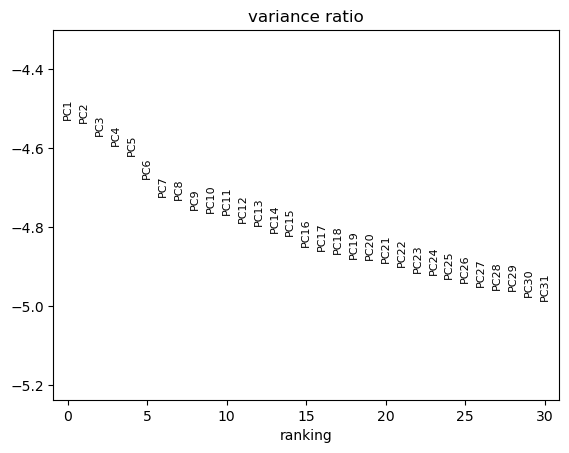

In [11]:
# run PCA (use 'arpack' for deterministic results; 'randomized' is faster on large data)
sc.tl.pca(ad, n_comps=50, svd_solver="arpack")

# plots
plt.rcParams["figure.facecolor"] = "white"
sc.pl.pca_variance_ratio(ad, log=True)          # scree + cumulative


You can tune the clustering/embedding behavior by adjusting three key parameters:

- **`n_neighbors`** (neighbors graph): controls local vs. global structure.  
  Smaller → more local, finer clusters. Larger → smoother, more global structure.  
  *Typical range:* 10–50 (start at 15–30).

- **`n_pcs`** (PCA dimensionality): how many principal components to use when building the graph.  
  Too few → miss structure; too many → add noise.  
  *Typical range:* 20–50 (match to your dataset size/complexity).

- **`min_dist`** (UMAP): how tightly points pack in the 2D embedding.  
  Smaller → tighter, more separated clusters. Larger → smoother, more blended.  
  *Typical range:* 0.1–0.8 (start at 0.3–0.5).

Refer to the Scanpy docs for deeper guidance. Below is a minimal pattern you can edit:


In [12]:
# Build nearest-neighbor graph using PCA space
sc.pp.neighbors(
    ad,
    n_neighbors=20,   # number of neighbors for graph construction
    n_pcs=40,         # number of principal components to use
    use_rep="X_pca"   # use PCA-reduced representation
)

# Compute UMAP embedding
sc.tl.umap(
    ad,
    min_dist=0.005,   # forces very compact, tight clusters
    random_state=0    # reproducibility
)


2025-09-01 11:21:48.100324: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/mnt/DATA/ext_home/saga/anaconda3/envs/ISS_postprocessing/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/mnt/DATA/ext_home

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/mnt/DATA/ext_home/saga/anaconda3/envs/ISS_postprocessing/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/mnt/DATA/ext_home/saga/anaconda3/envs/ISS_postprocessing/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/mnt/DATA/ext_home/saga/anaconda3/envs/ISS_postprocessing/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/mnt/DATA/ext_home/saga/anaconda3/en

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/mnt/DATA/ext_home/saga/anaconda3/envs/ISS_postprocessing/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/mnt/DATA/ext_home/saga/anaconda3/envs/ISS_postprocessing/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/mnt/DATA/ext_home/saga/anaconda3/envs/ISS_postprocessing/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/mnt/DATA/ext_home/saga/anaconda3/en

AttributeError: _ARRAY_API not found

ImportError: numpy.core._multiarray_umath failed to import

We visualize two Leiden clustering resolutions (e.g., 1.0 and 2.0) on the UMAP to compare cluster granularity. Lower resolution yields fewer, broader clusters; higher resolution yields more, finer clusters. The code below overlays each result on the UMAP for side-by-side inspection.


clustering @ resolution 1.0


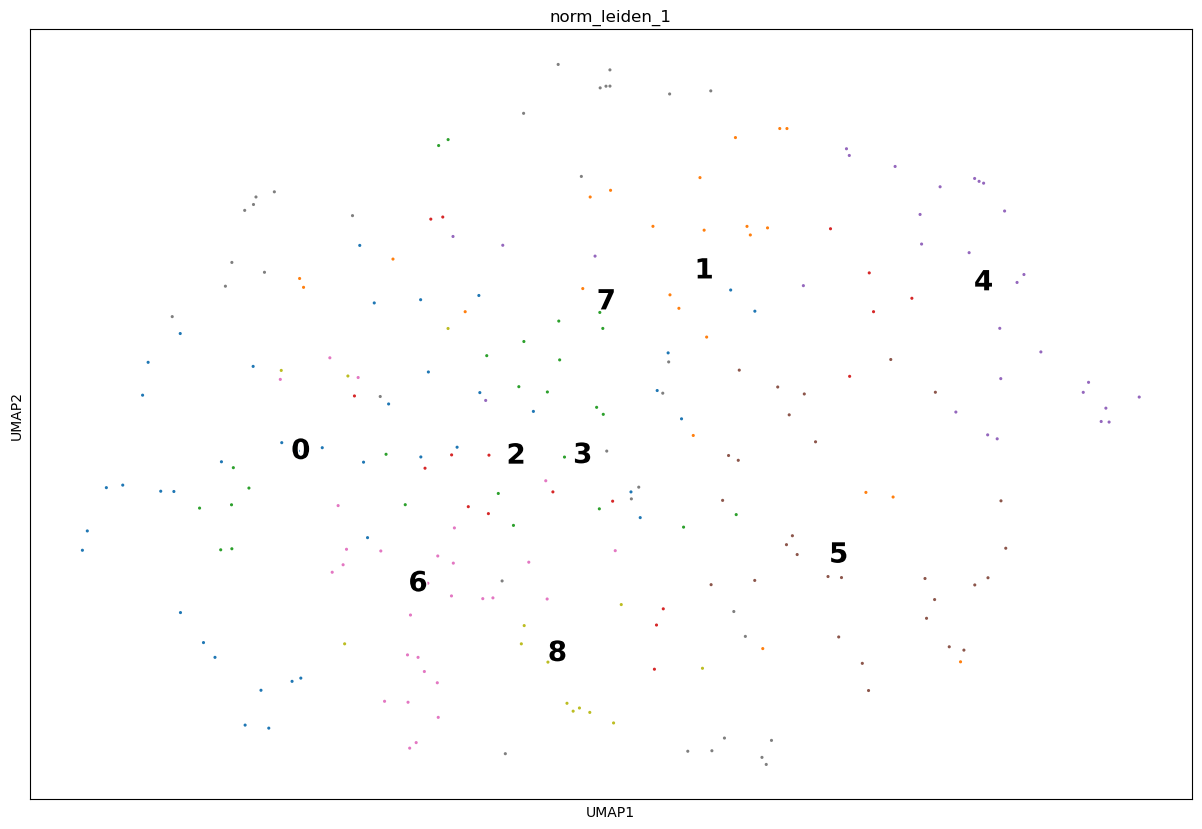

clustering @ resolution 2.0


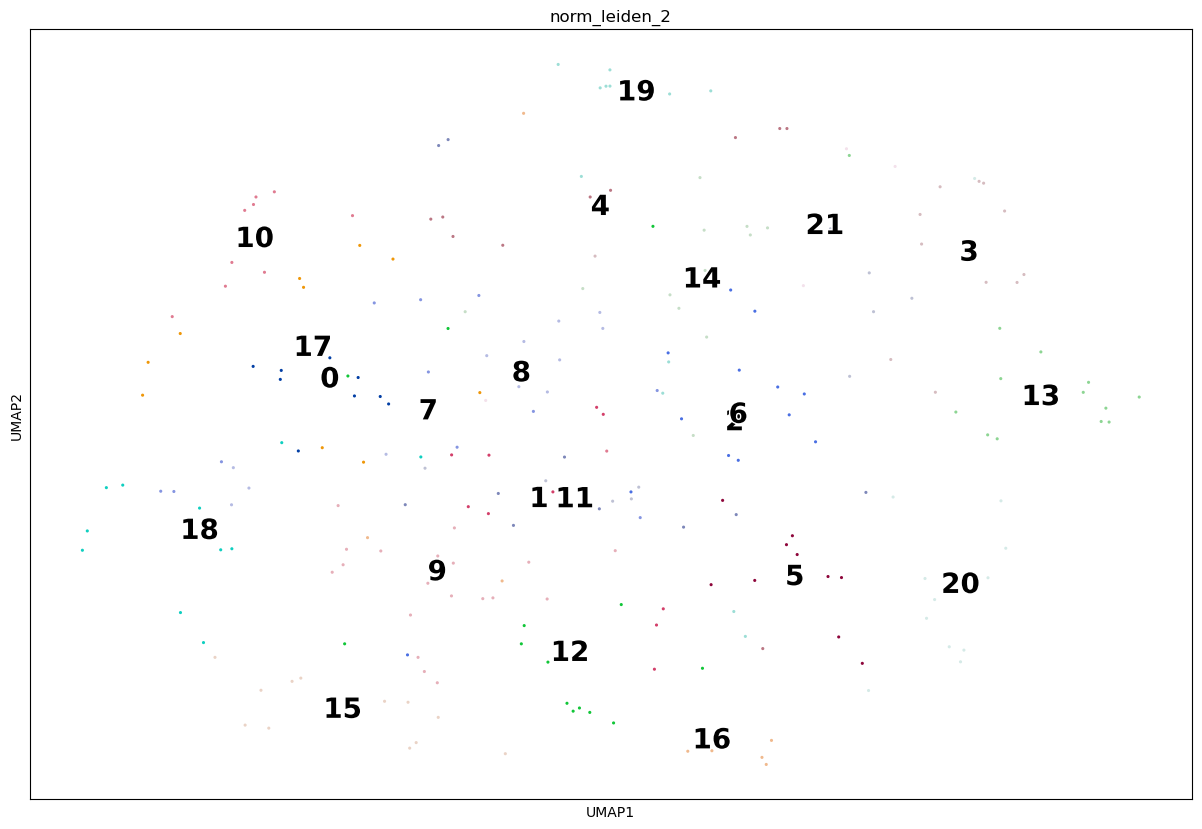

In [13]:
# Pick resolutions to visualize
res_list = [1.0, 2.0]

for res in res_list:
    key = f"norm_leiden_{int(res) if res.is_integer() else res}"

    if key not in ad.obs.columns:
        print(f"clustering @ resolution {res}")
        sc.tl.leiden(
            ad,
            resolution=res,
            key_added=key,
            random_state=0,
            flavor="igraph",     # future default
            n_iterations=2,      # required for igraph flavor
            directed=False       # igraph needs directed=False
        )

    plt.rcdefaults()
    with plt.rc_context({"figure.figsize": (15, 10)}):
        sc.pl.umap(
            ad,
            color=key,
            s=20,
            add_outline=False,
            legend_loc="on data",
            legend_fontsize=20,
            legend_fontoutline=2,
        )




## Extracting cell positions

This block of code takes the `x` and `y` coordinates stored in `ad.obs` and saves them into `ad.obsm`.  
The `obsm['spatial']` slot is the **standard location** that Scanpy and many spatial tools expect for plotting.  

We also store them as `obsm['xy_loc']` (optional), in case other downstream functions rely on that naming.



In [14]:
# Ensure columns exist and are float64
xy = ad.obs[["x", "y"]].astype(np.float64).to_numpy(copy=False)

# Store in the conventional slot used by many tools/plots
ad.obsm["spatial"] = xy

# Optional duplicate if other code expects this name
ad.obsm["xy_loc"] = xy


And finally here we can plot the **spatial distribution of the different clusters** in one go.

R1


/tmp/ipykernel_152638/3669563464.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


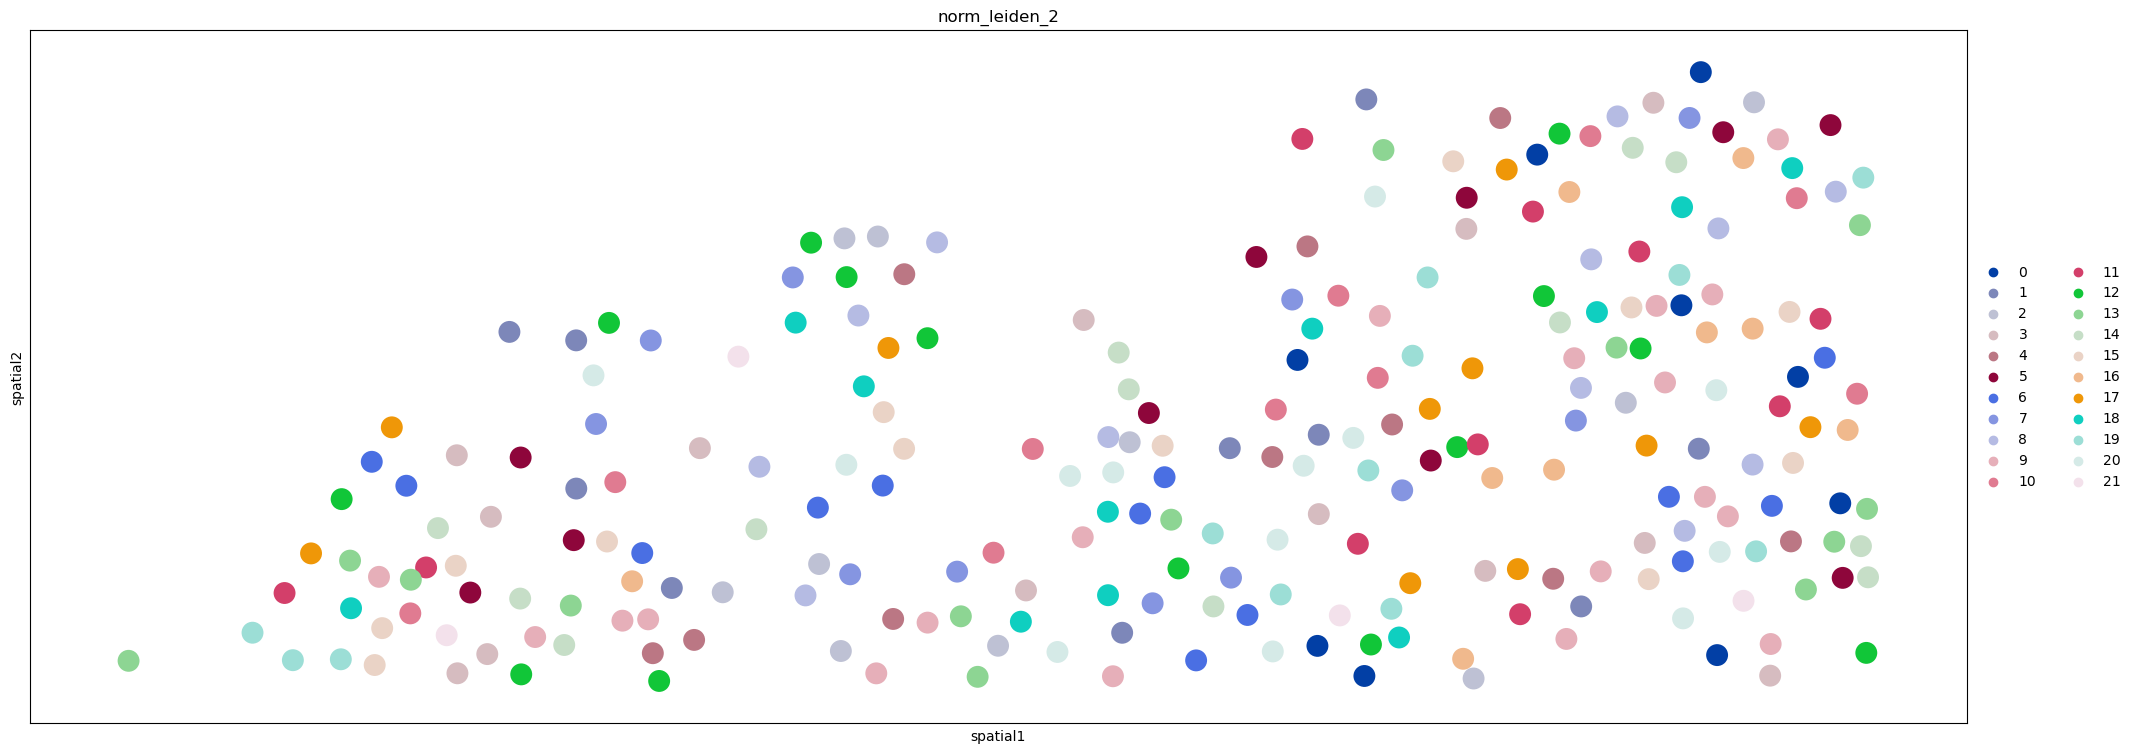

In [15]:
cluster = 'norm_leiden_2'   # choose which clustering column to plot

for region in ad.obs['region_id'].unique():   # loop over unique regions
    print(region)
    ad_int = ad[ad.obs['region_id'] == region]   # subset AnnData to just this region
    
    with plt.rc_context({'figure.figsize': (25, 17.5)}):   # temporarily set figure size
        sc.pl.spatial(
            ad_int,
            color=cluster,      # color cells by cluster assignment
            spot_size=30        # dot size in the plot
        )


/tmp/ipykernel_152638/3402355613.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


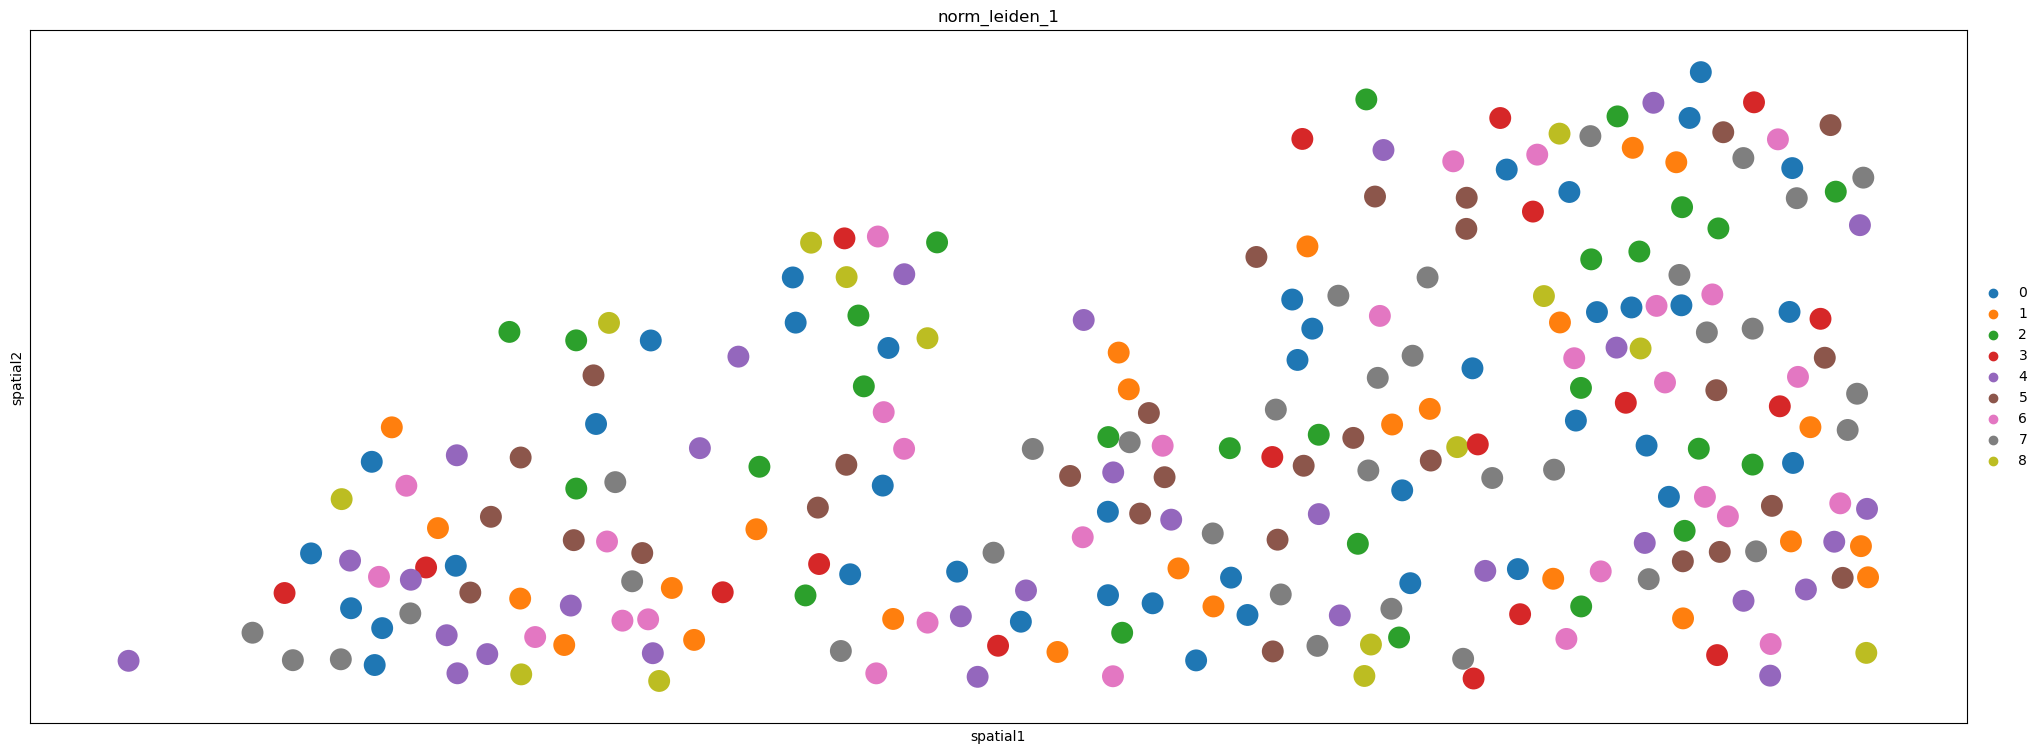

In [16]:
cluster = 'norm_leiden_1'   # pick clustering column
ad_int = ad                 # here you're not subsetting, just using everything

with plt.rc_context({'figure.figsize': (25, 17.5)}):
    sc.pl.spatial(
        ad_int,
        color=cluster,   # color cells by Leiden cluster
        spot_size=30     # size of each dot in the scatter
    )


## Which genes are good markers of the ISS clusters?

By running the following code blocks, you can identify the genes that
characterize each of the ISS clusters inferred above. The output can be
visualized using different types of plots, which present the same
information in either a more condensed or a more detailed format.


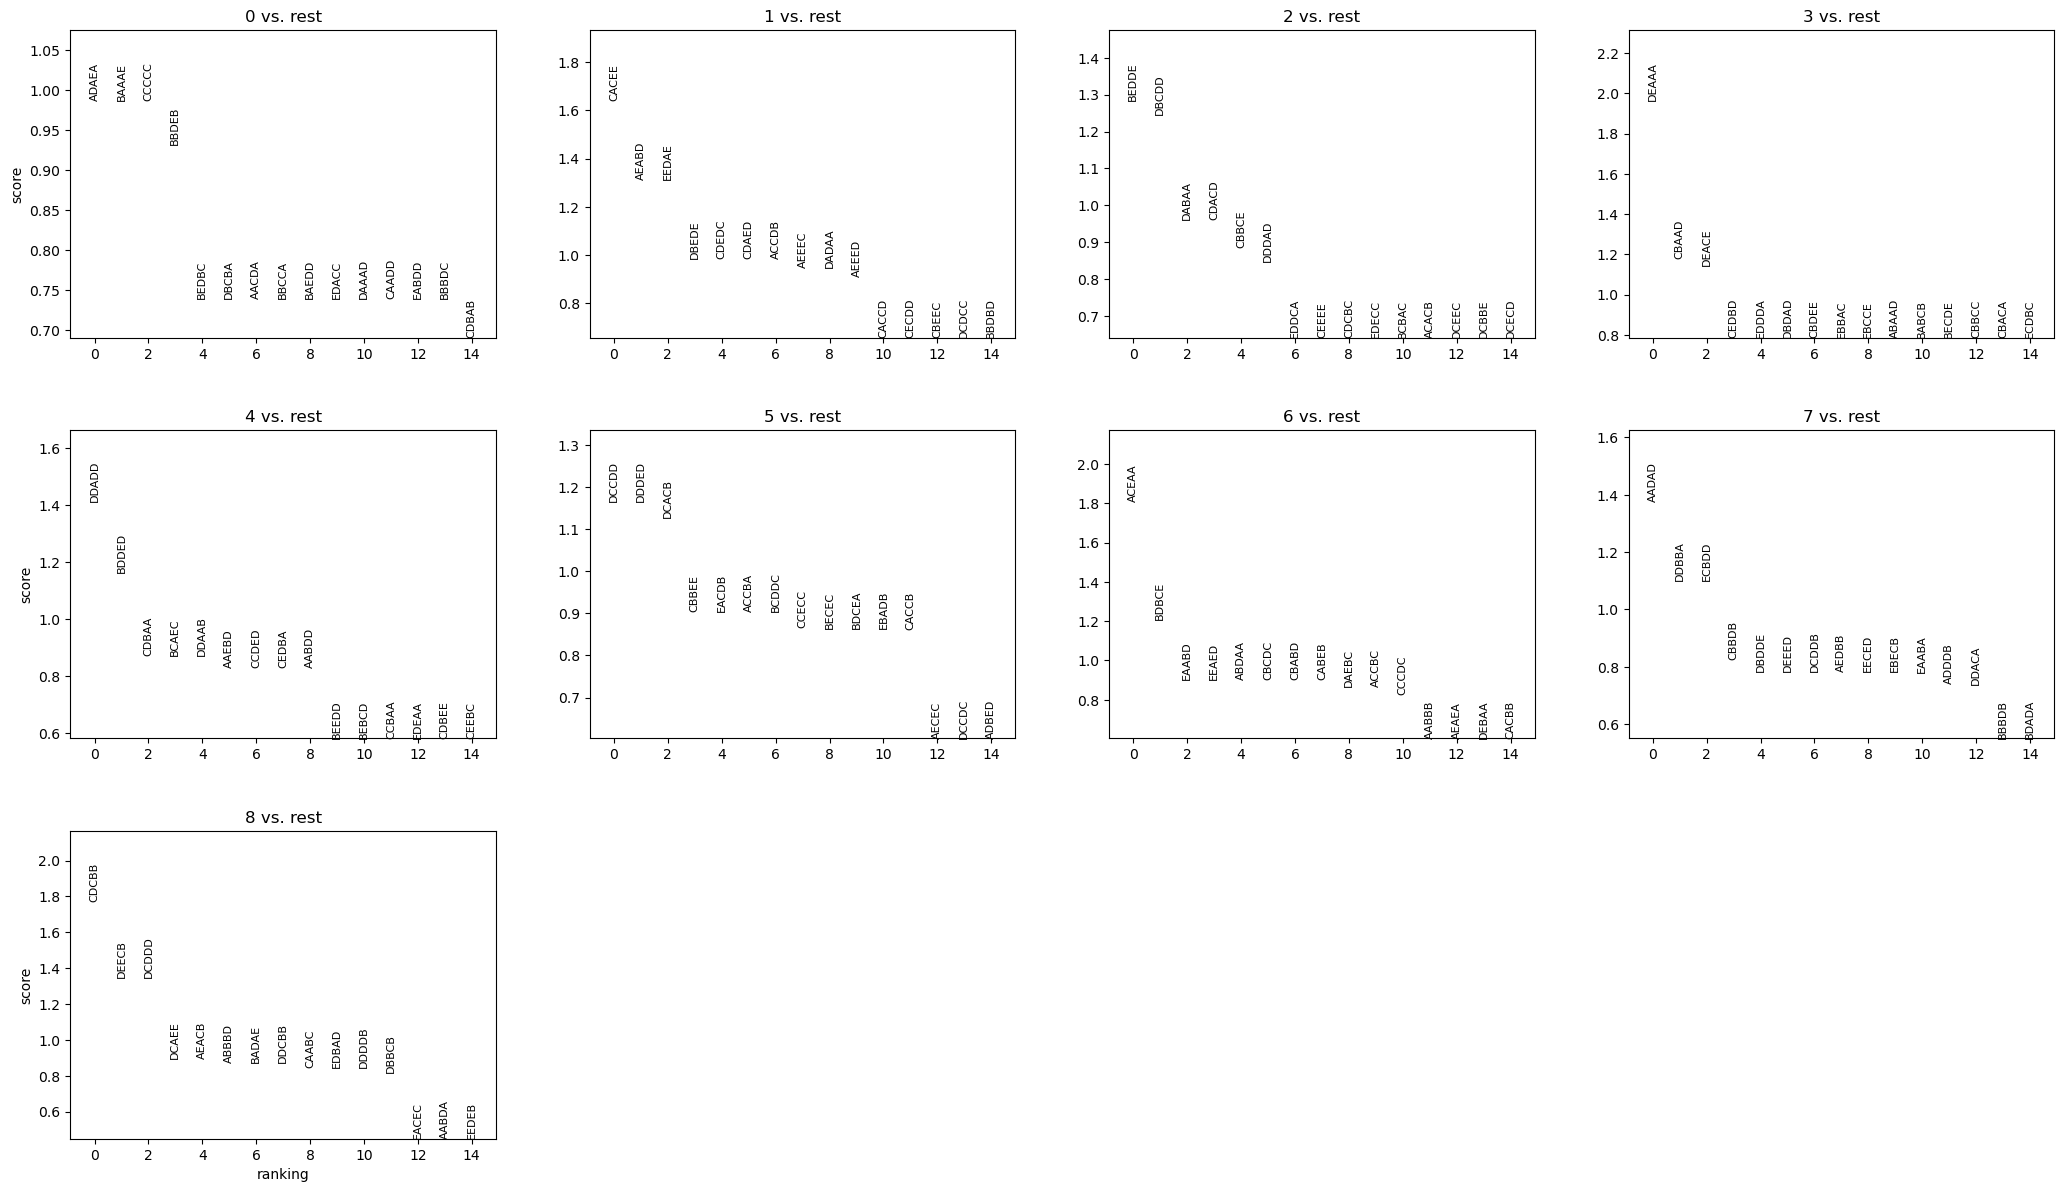

In [17]:
# Identify marker genes for each cluster using a Wilcoxon test
sc.tl.rank_genes_groups(
    ad, 
    groupby=cluster, 
    method="wilcoxon", 
    key_added=cluster + "_wilcoxon"
)

# Visualize the top 15 marker genes per cluster
sc.pl.rank_genes_groups(
    ad, 
    n_genes=15, 
    sharey=False, 
    key=cluster + "_wilcoxon"
)


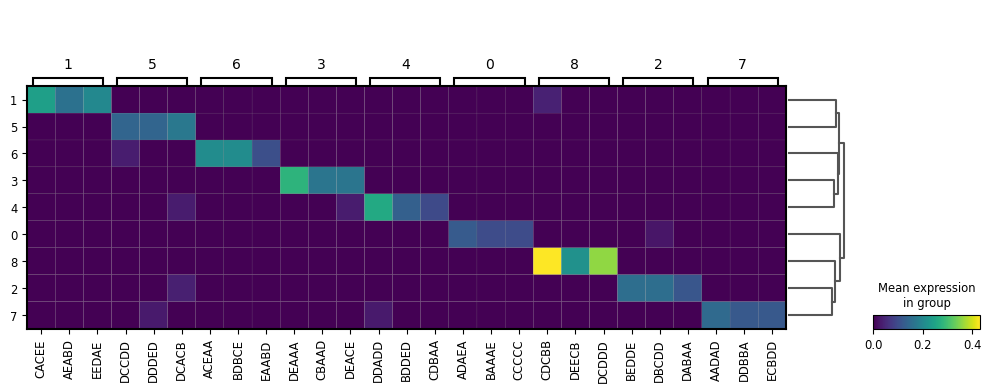

In [18]:
# Reset matplotlib defaults (optional, ensures consistent styling)
plt.rcdefaults()

# Show top 3 marker genes per cluster as a matrix plot
sc.pl.rank_genes_groups_matrixplot(
    ad,
    n_genes=3,
    key=cluster + "_wilcoxon",
    groupby=cluster,
    cmap="viridis"
)


## Save the updated AnnData object

The following code saves an updated version of the AnnData object,
including all calculations performed above. Specifically, the saved file
will contain:

- UMAP representations  
- Differentially expressed genes by cluster  
- Spatial coordinates of the cells  


In [19]:
# Save the updated AnnData object to your specified directory
output_path = Path(input_dir) / 'All regions' / 'postprocessing' / 'segmentation' / "anndata_cellpose.h5ad"
output_path.parent.mkdir(parents=True, exist_ok=True)  # make sure folder exists

ad.write(output_path)
print(f"AnnData saved to: {output_path}")



AnnData saved to: /mnt/DATA/ext_home/saga/test/saga/output_tif_autosaved/redlionfish/All regions/postprocessing/segmentation/anndata_cellpose.h5ad


## Generate figures for each cluster

The following code will generate a figure for each cluster. For every
sample, all clusters are plotted together in a single figure, along with
a short list of their unique marker genes.


In [20]:
# Add a project label to the AnnData object
ad.obs["project"] = "sc"


Processing cluster 0...


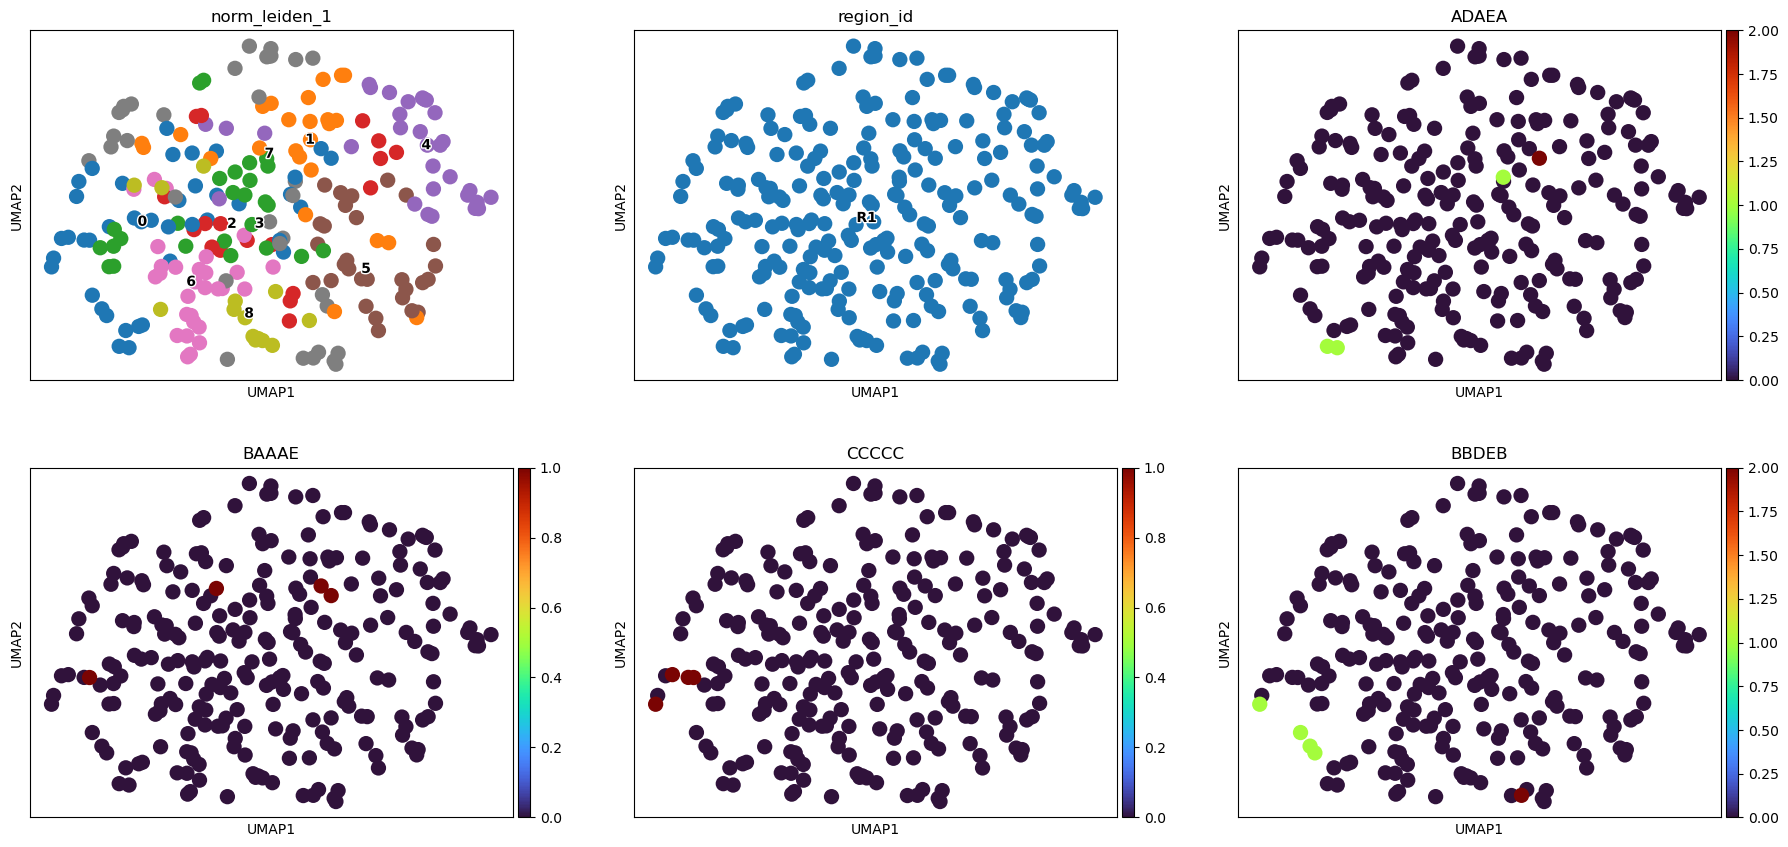


Marker genes for cluster 0 in sc:
ADAEA BAAAE CCCCC BBDEB BEDBC DBCBA AACDA BBCCA BAEDD EDACC


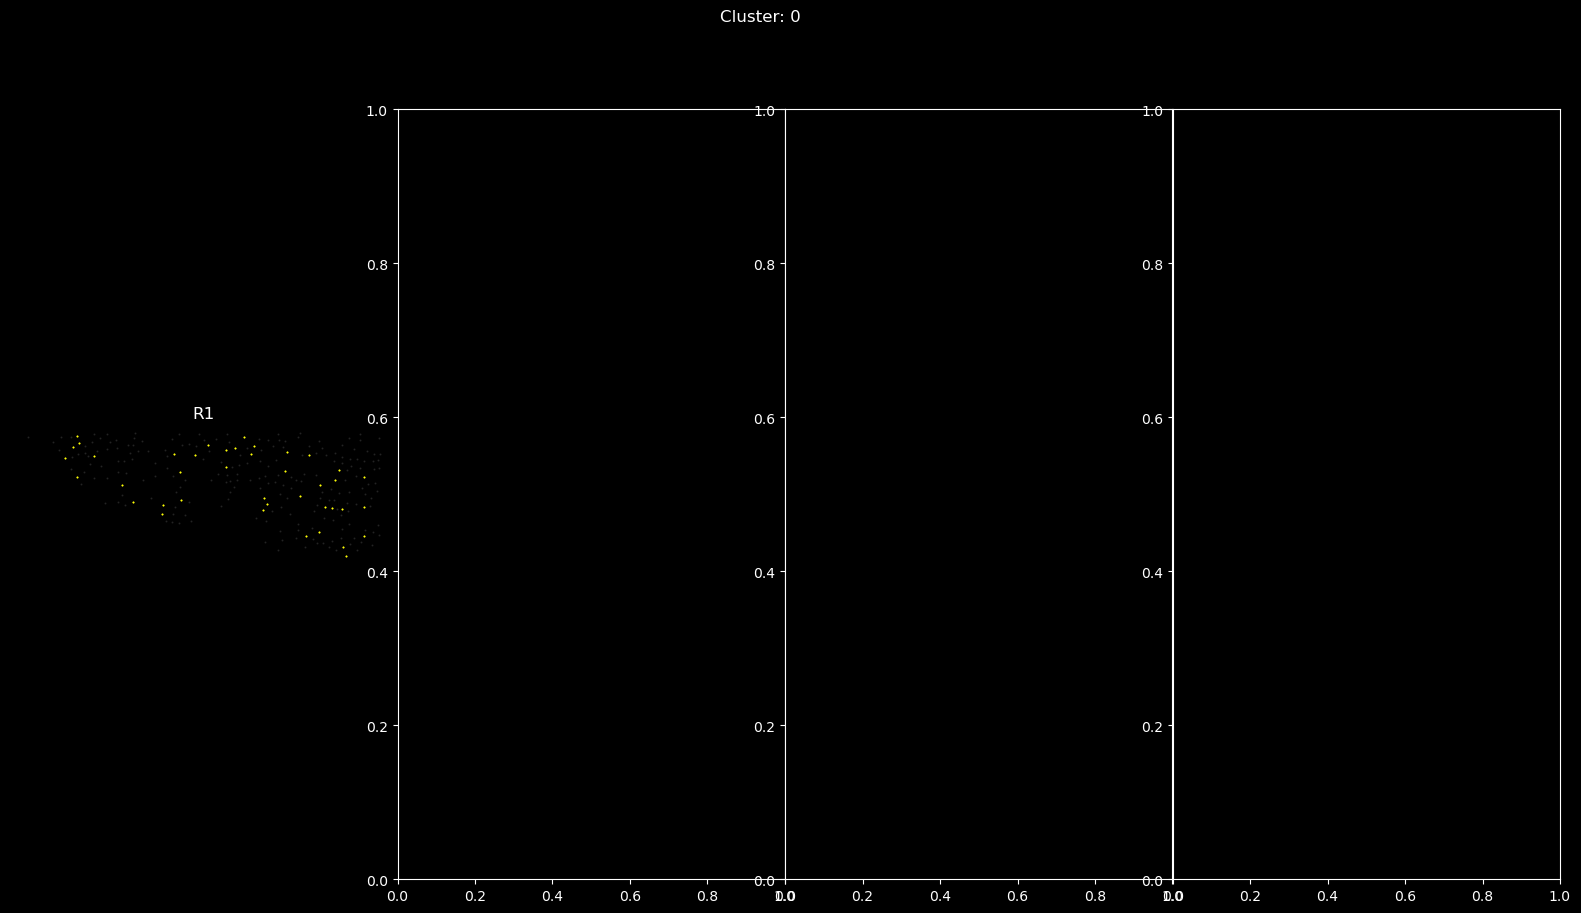

Processing cluster 4...


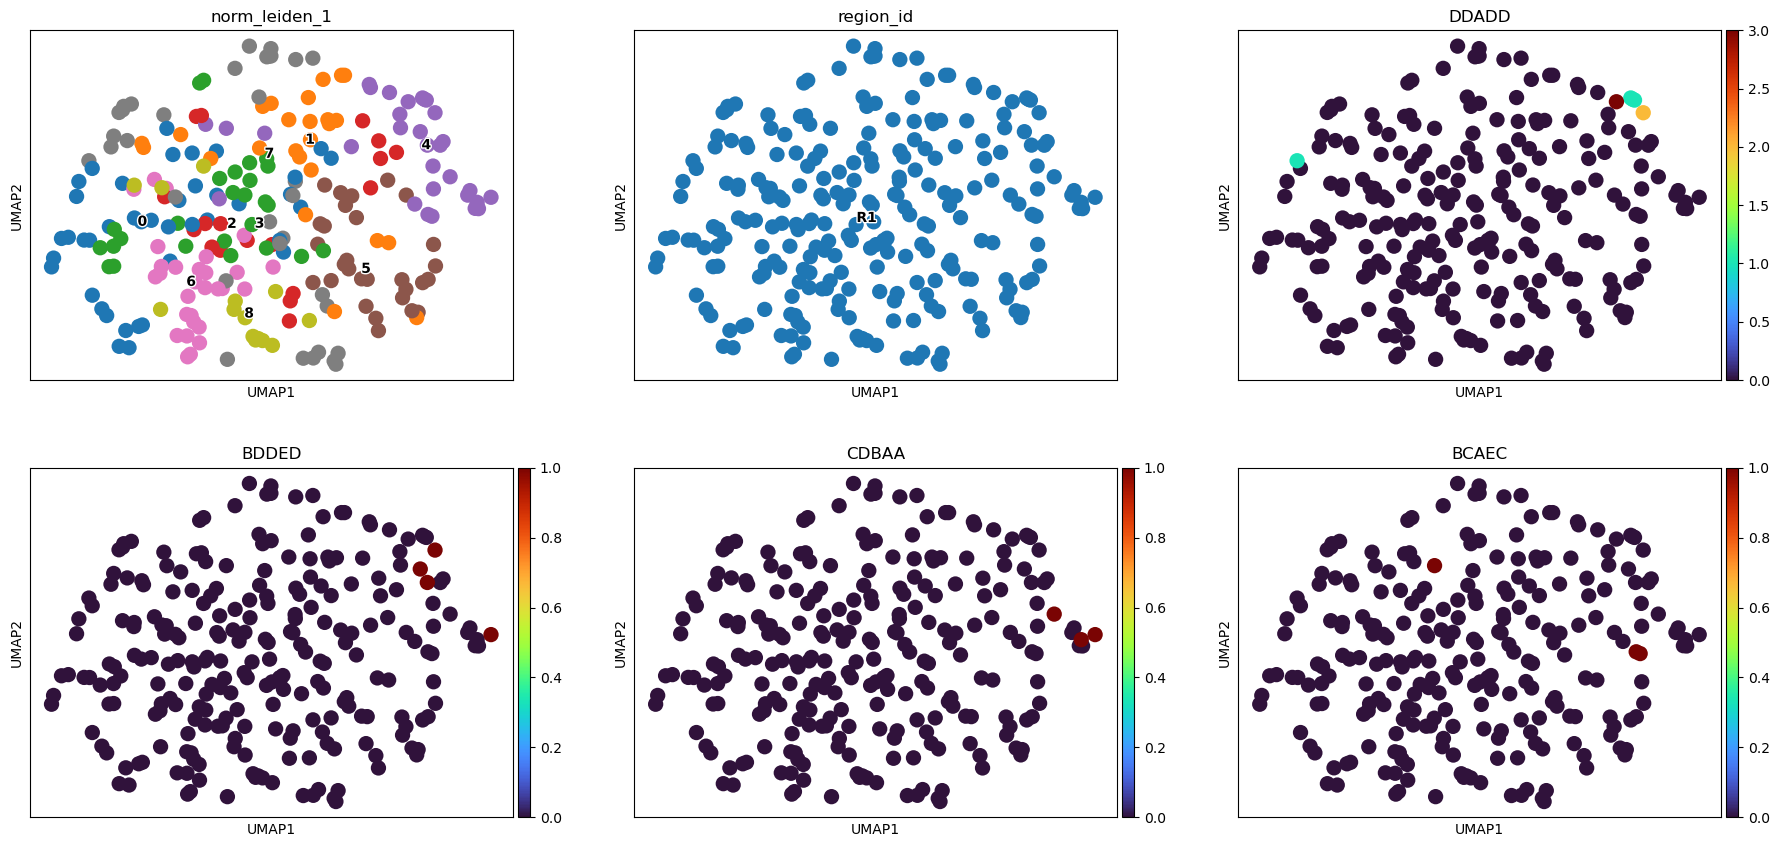


Marker genes for cluster 4 in sc:
DDADD BDDED CDBAA BCAEC DDAAB AAEBD CCDED CEDBA AABDD BEEDD


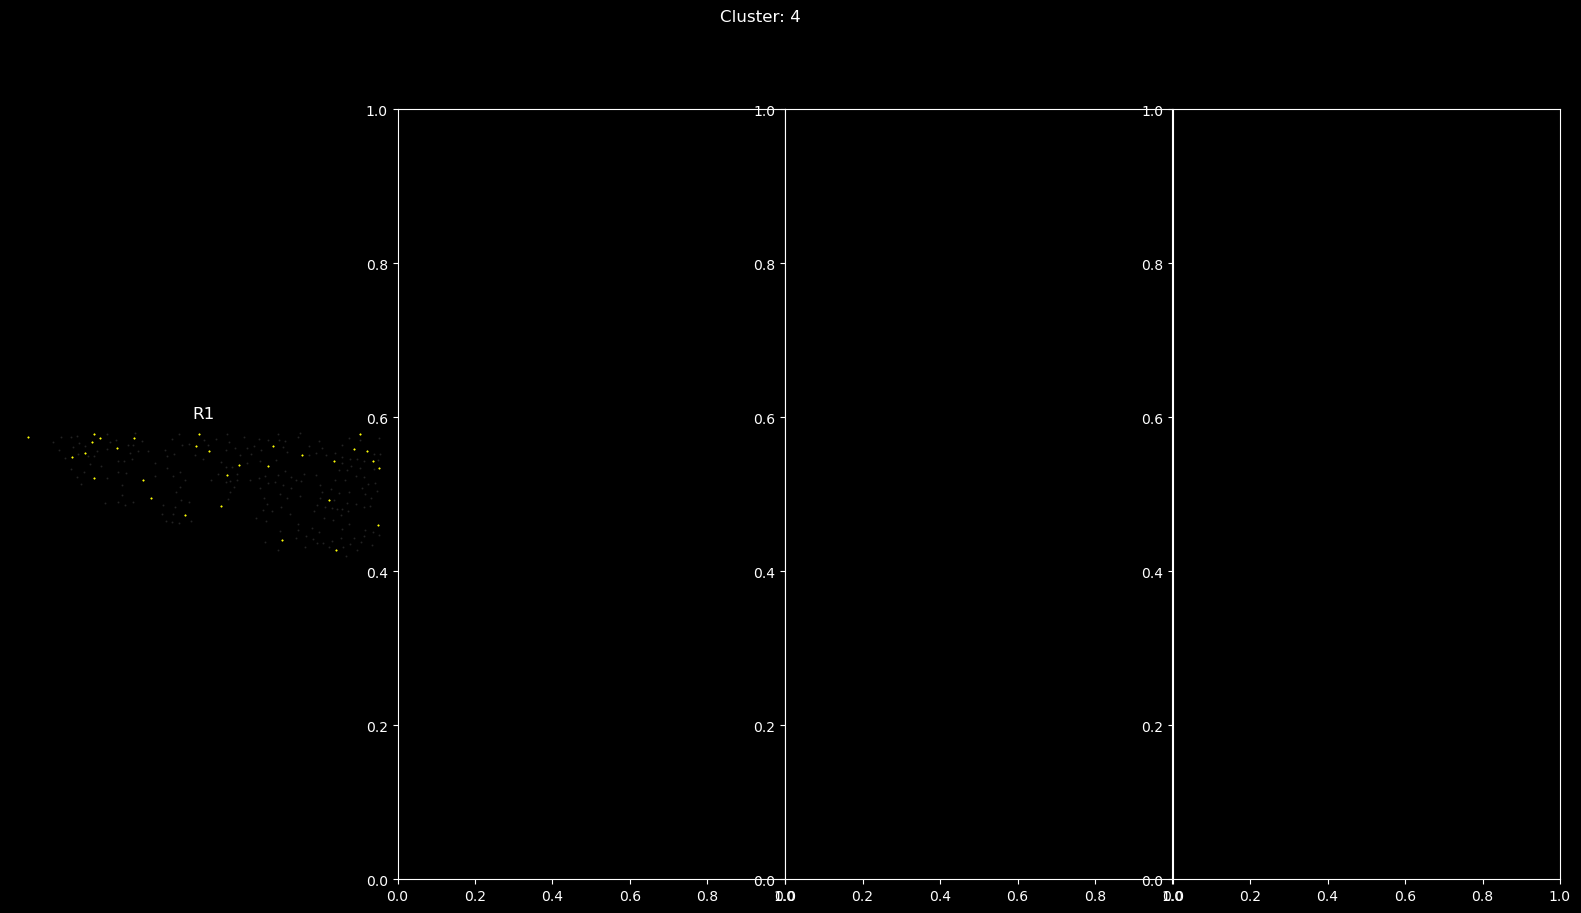

Processing cluster 5...


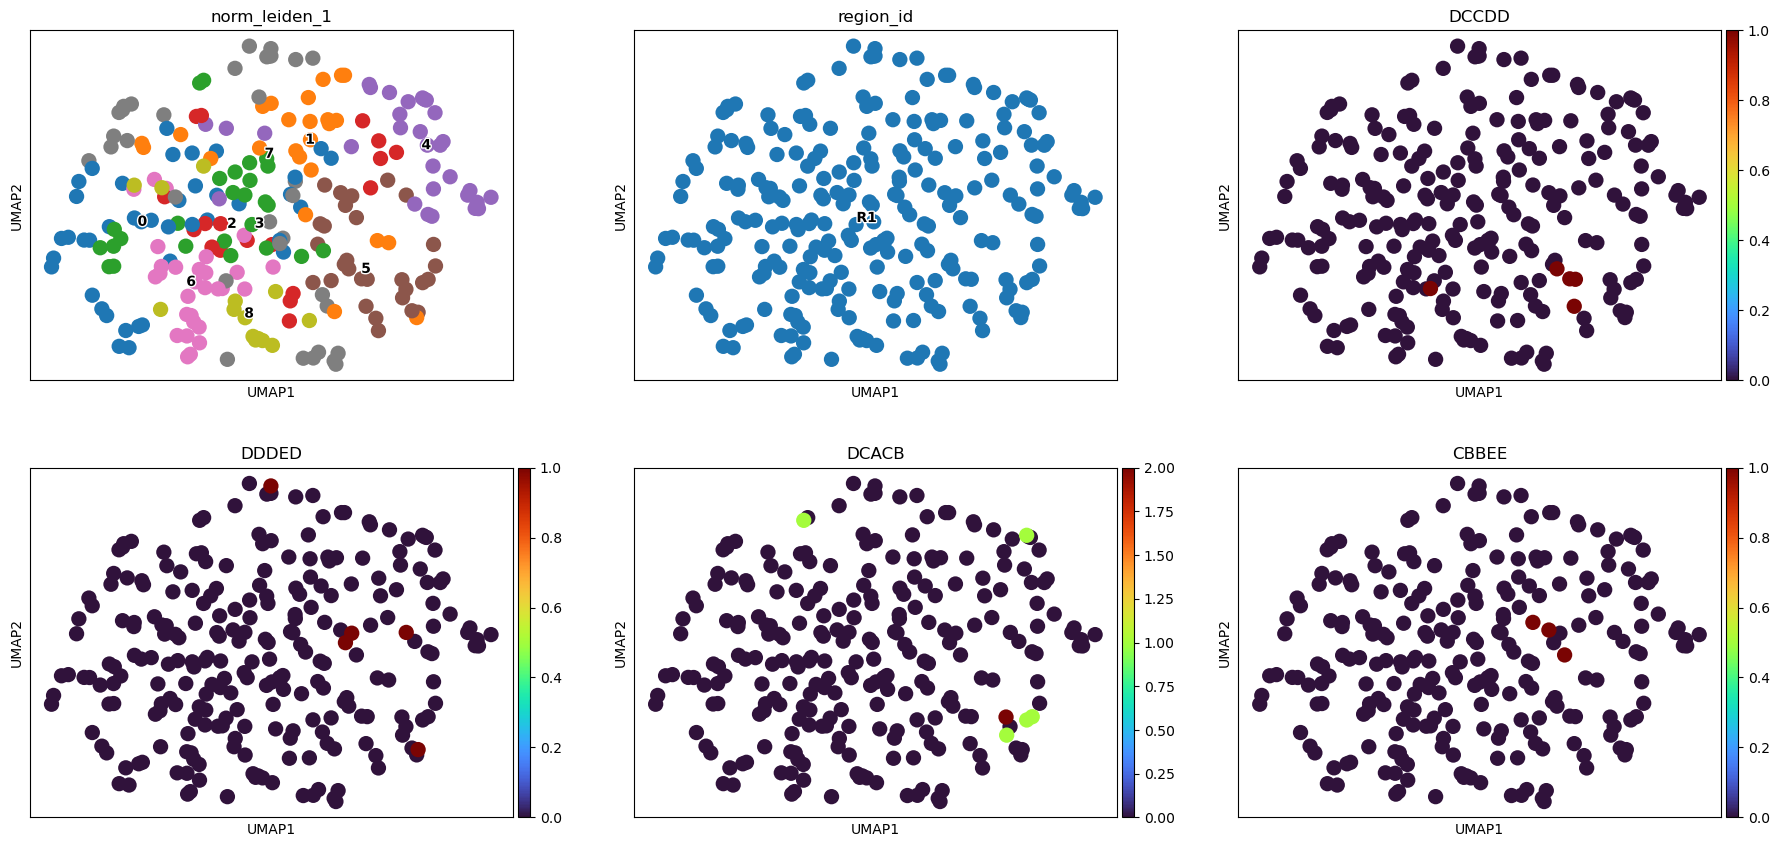


Marker genes for cluster 5 in sc:
DCCDD DDDED DCACB CBBEE EACDB ACCBA BCDDC CCECC BECEC BDCEA


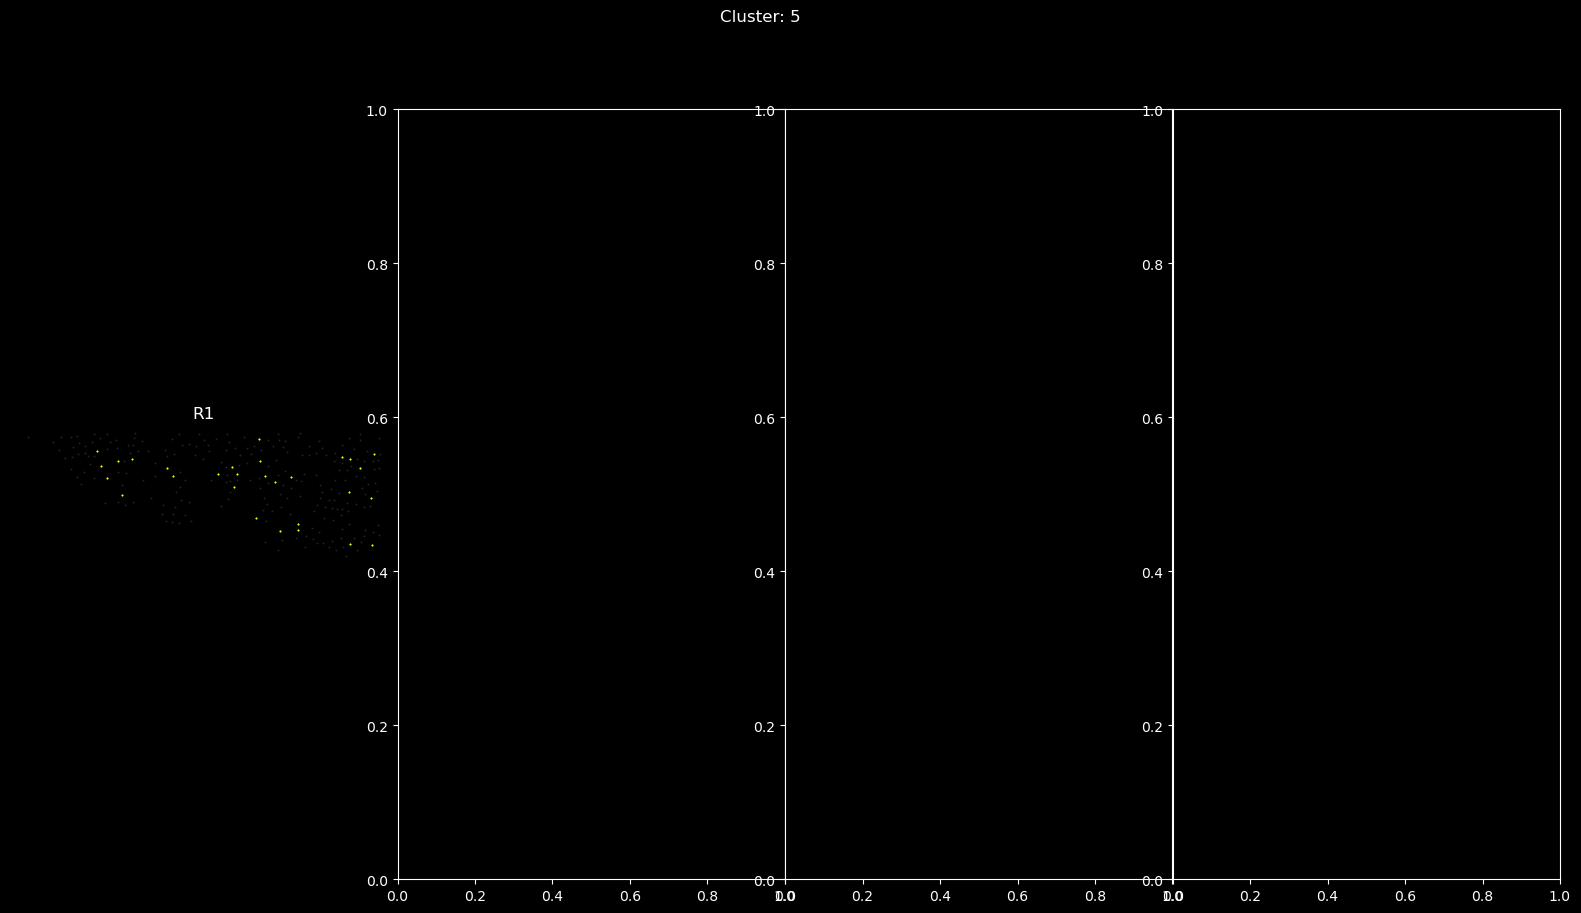

Processing cluster 6...


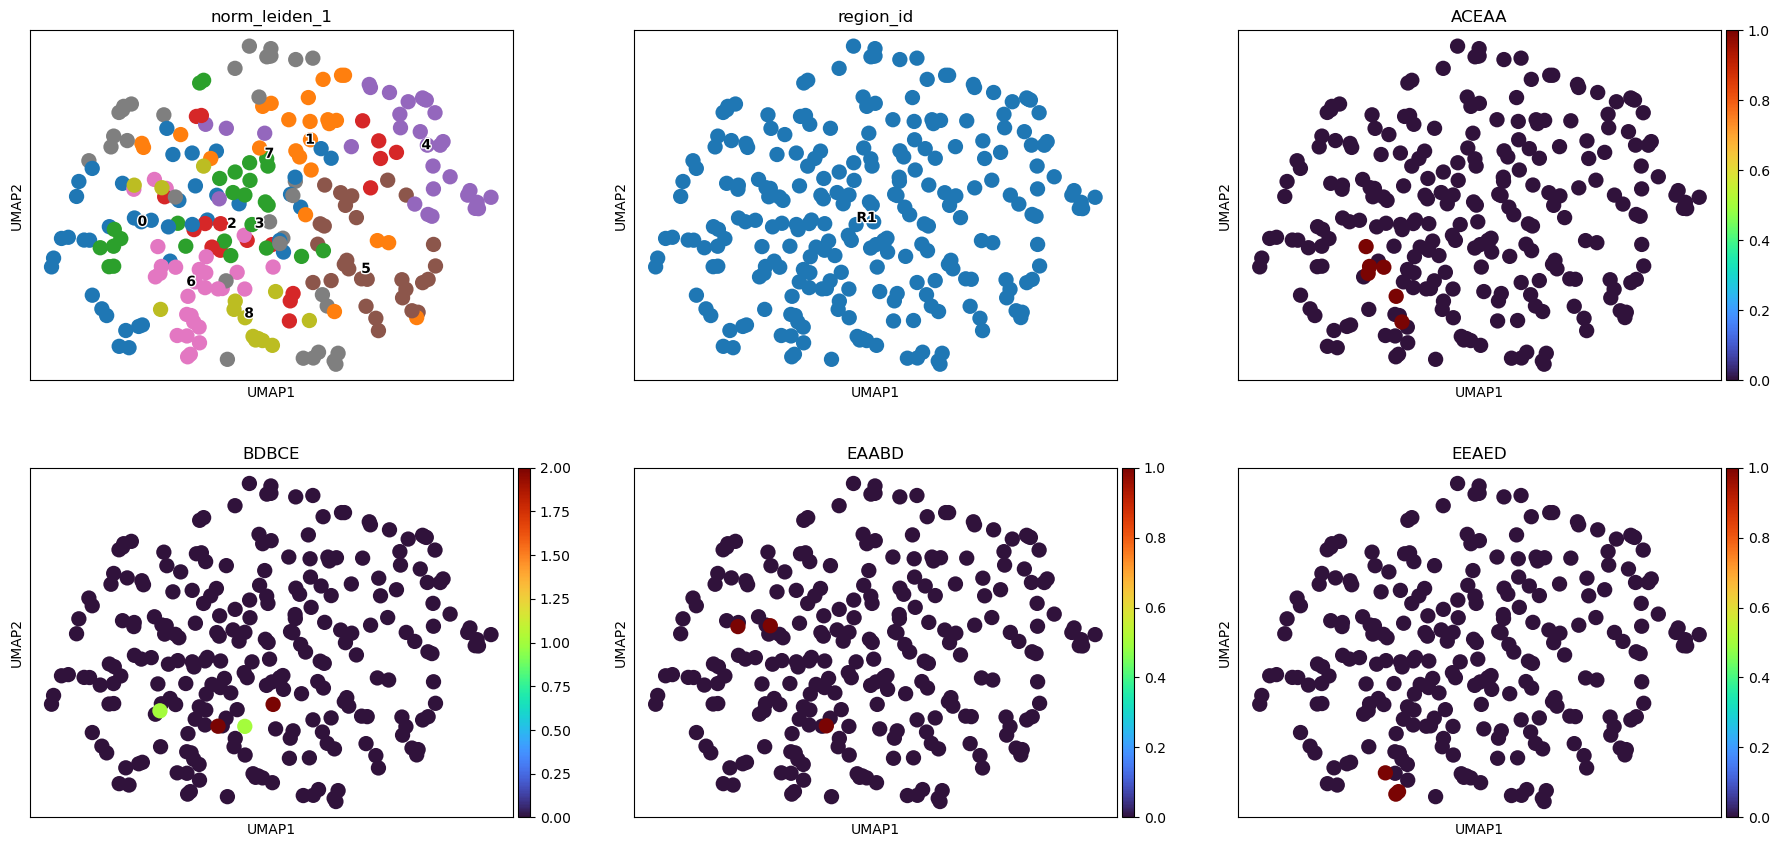


Marker genes for cluster 6 in sc:
ACEAA BDBCE EAABD EEAED ABDAA CBCDC CBABD CABEB DAEBC ACCBC


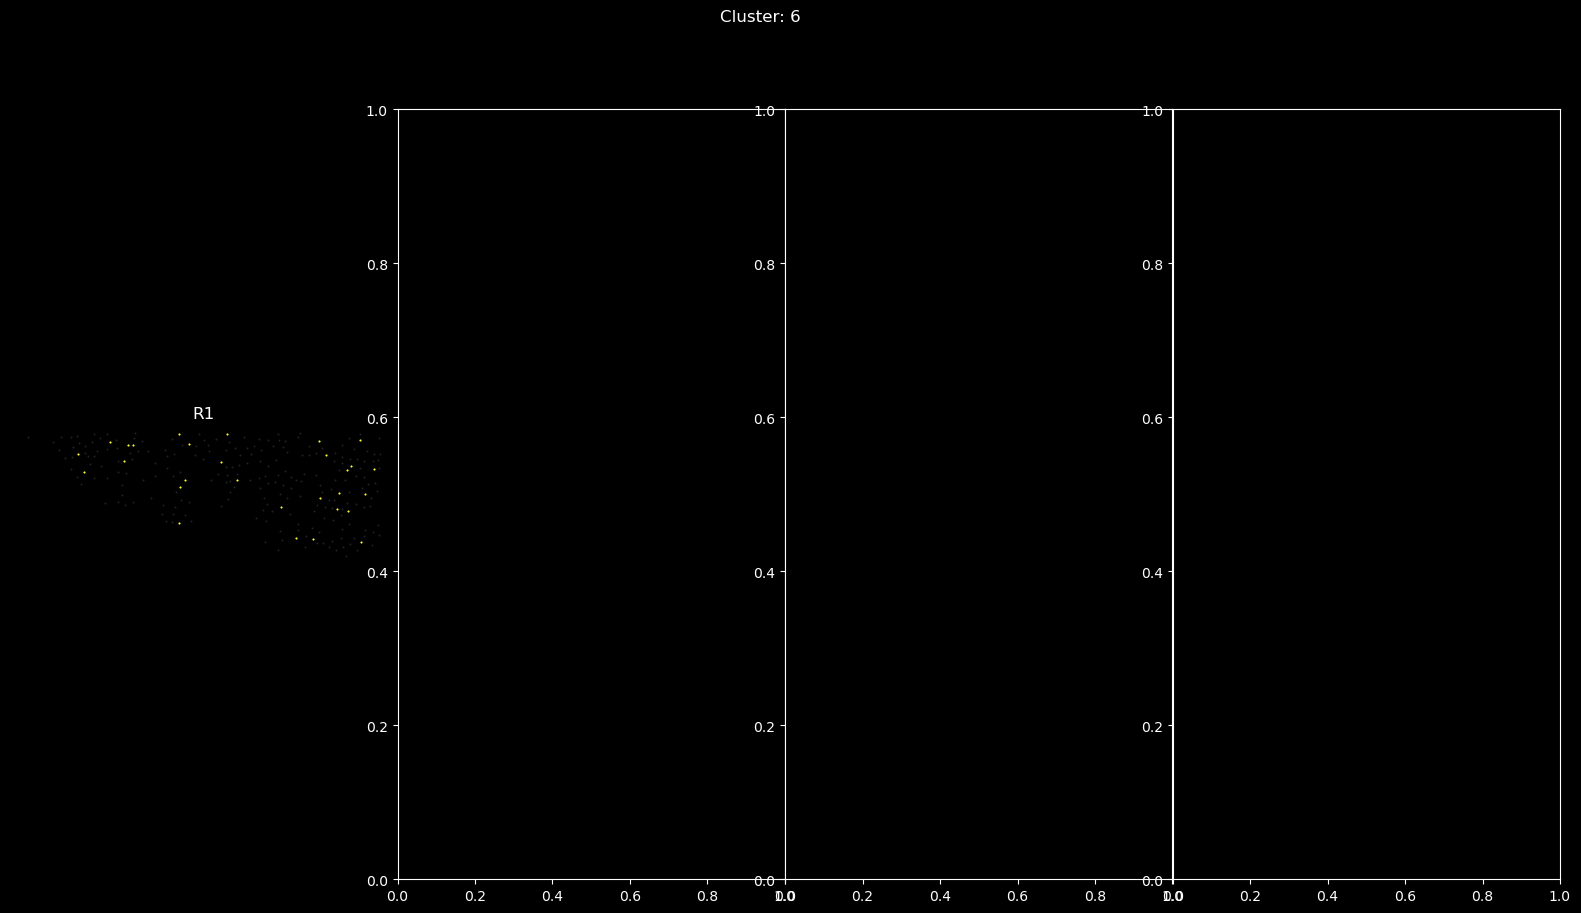

Processing cluster 7...


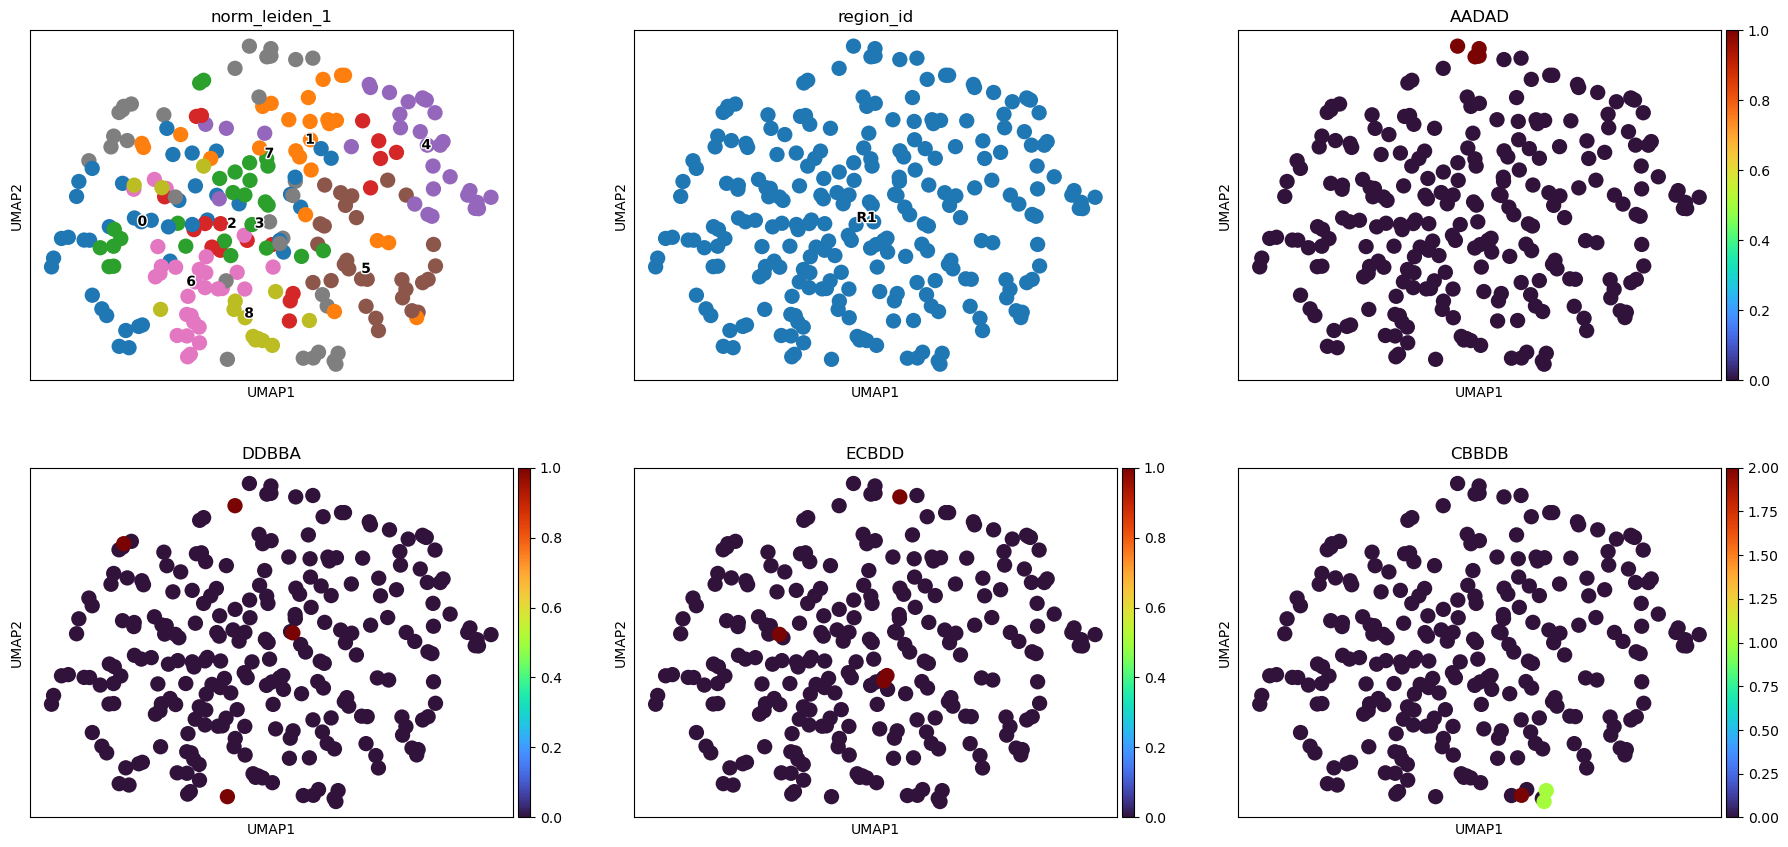


Marker genes for cluster 7 in sc:
AADAD DDBBA ECBDD CBBDB DBDDE DEEED DCDDB AEDBB EECED EBECB


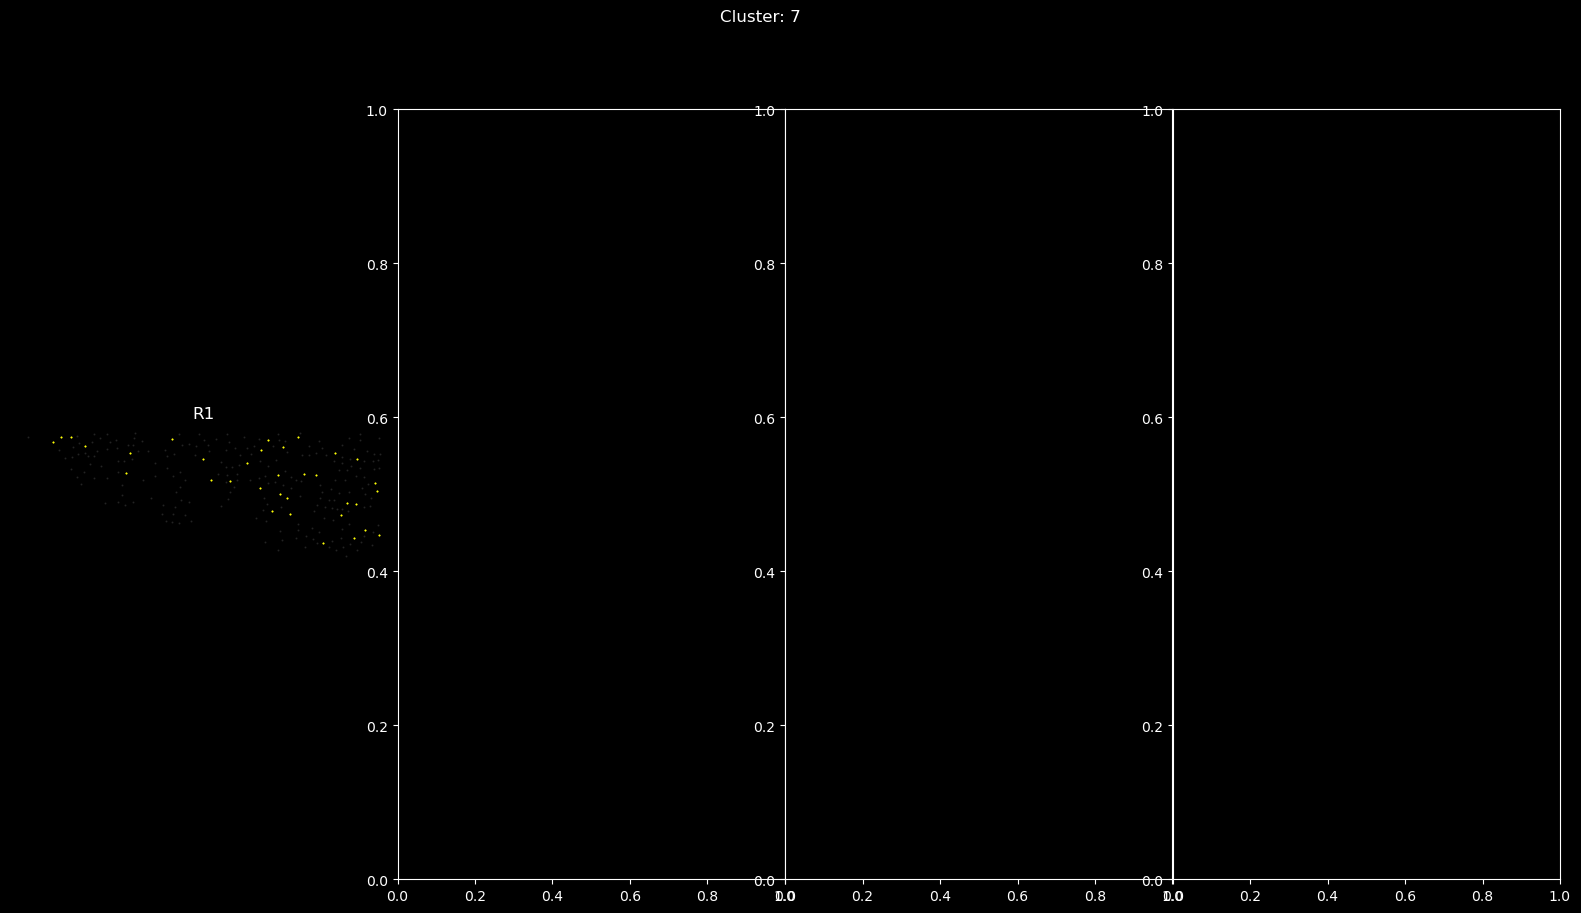

In [21]:
# Loop through the top 5 most frequent clusters
for cluster_ in sorted(ad.obs[cluster].value_counts().head(5).index.astype(int)):
    print(f"Processing cluster {cluster_}...")

    # Dynamically choose the correct key (e.g., norm_leiden_1_wilcoxon)
    key = f"{cluster}_wilcoxon"
    if key not in ad.uns:
        raise KeyError(f"[ERROR] Rank genes results not found: {key}. "
                       f"Did you run sc.tl.rank_genes_groups(ad, groupby='{cluster}', method='wilcoxon')?")

    # Get the top 4 marker genes
    genes = list(
        sc.get.rank_genes_groups_df(
            ad,
            group=str(cluster_),
            key=key
        )["names"].head(4)
    )

    # Add cluster and region identifiers for UMAP coloring
    genes.insert(0, cluster)       # cluster labels
    genes.insert(1, "region_id")   # region identifiers

    # Reset matplotlib defaults
    plt.rcdefaults()

    # UMAP visualization
    sc.pl.umap(
        ad,
        color=genes,
        cmap="turbo",
        ncols=3,
        legend_loc="on data",
        legend_fontsize=10,
        legend_fontoutline=2
    )

    # Spatial visualization
    ANN.plot_specific_cluster(
        ad,
        clusters_to_map=cluster,
        cluster=str(cluster_),
        broad_cluster="project",
        key=key,   
        size=0.5,
        number_of_marker_genes=10,
        region_id_column="region_id",
        dim_subplots=[4, 4]
    )

    plt.show()
